In [7]:
import cv2, os

pasta = "imagens_experimentais"
largura_maxima = 800  # Mantém o resize para proteger sua RAM

imagens = []
for f in sorted(os.listdir(pasta)):
    if f.lower().endswith(('.png', '.jpg', '.jpeg')):
        img = cv2.imread(os.path.join(pasta, f))
        
        if img is not None:
            # Redimensiona proporcionalmente para economizar memória
            altura, largura = img.shape[:2]
            if largura > largura_maxima:
                proporcao = largura_maxima / float(largura)
                nova_altura = int(altura * proporcao)
                img = cv2.resize(img, (largura_maxima, nova_altura), interpolation=cv2.INTER_AREA)
            
            # Adiciona direto no array (pode deixar em BGR mesmo já que não vai plotar)
            imagens.append(img)

# Apenas avisa que terminou
if imagens:
    print(f"As imagens foram geradas com sucesso! Total no array: {len(imagens)}")
else:
    print("Nenhuma imagem válida foi carregada.")

As imagens foram geradas com sucesso! Total no array: 150


In [9]:
import os
import json
import cv2
import numpy as np

def carregar_dados_originais(caminho_img, caminho_json):
    """
    Carrega a imagem original mantendo a estrutura RGB de 8 bits
    e lê o arquivo de anotação correspondente (Ground Truth).
    """
    img_bgr = cv2.imread(caminho_img, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"Não foi possível carregar a imagem em: {caminho_img}")
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    with open(caminho_json, 'r', encoding='utf-8') as f:
        dados_gt = json.load(f)
        
    return img_rgb, dados_gt

def adicionar_ruido_gaussiano_rgb(imagem, desvio_padrao, semente=42):
    """
    Aplica ruído gaussiano aditivo n_c ~ N(0, sigma^2) 
    independentemente em cada um dos três canais (R, G, B).
    """
    rng = np.random.default_rng(semente)
    ruido = rng.normal(0, desvio_padrao, imagem.shape)
    
    img_degradada = imagem.astype(np.float64) + ruido
    img_degradada = np.clip(img_degradada, 0, 255).astype(np.uint8)
    return img_degradada

def adicionar_ruido_sal_e_pimenta_rgb(imagem, densidade, semente=42):
    """
    Seleciona aleatoriamente uma fração (p) dos pixels.
    Metade vira Sal [255, 255, 255] e metade vira Pimenta [0, 0, 0].
    """
    img_degradada = imagem.copy()
    altura, largura, canais = imagem.shape
    total_pixels = altura * largura
    
    rng = np.random.default_rng(semente)
    num_pixels_ruido = int(densidade * total_pixels)
    indices_corrompidos = rng.choice(total_pixels, size=num_pixels_ruido, replace=False)
    
    metade = num_pixels_ruido // 2
    indices_sal = indices_corrompidos[:metade]
    indices_pimenta = indices_corrompidos[metade:]
    
    linhas_sal, colunas_sal = np.unravel_index(indices_sal, (altura, largura))
    linhas_pimenta, colunas_pimenta = np.unravel_index(indices_pimenta, (altura, largura))
    
    img_degradada[linhas_sal, colunas_sal] = [255, 255, 255]
    img_degradada[linhas_pimenta, colunas_pimenta] = [0, 0, 0]
    
    return img_degradada

def gerar_dataset_experimental(diretorio_entrada, diretorio_saida, semente_base=42):
    """
    Varre o diretório de entrada, gera as 4 versões degradadas de cada imagem
    e duplica os respectivos arquivos JSON com os nomes corrigidos.
    """
    if not os.path.exists(diretorio_saida):
        os.makedirs(diretorio_saida)
        
    # Listar todos os arquivos de imagem no diretório de entrada
    arquivos = [f for f in os.listdir(diretorio_entrada) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if not arquivos:
        print(f"Aviso: Nenhuma imagem encontrada na pasta '{diretorio_entrada}'.")
        return

    # Configurações solicitadas pelo enunciado
    config_degradacoes = {
        "gauss_baixo":  {"tipo": "gauss", "param": 5},
        "gauss_medio":  {"tipo": "gauss", "param": 15},
        "sp_baixo":     {"tipo": "sp",    "param": 0.01},
        "sp_medio":     {"tipo": "sp",    "param": 0.05}
    }
    
    print(f"Iniciando o processamento de {len(arquivos)} imagens...")
    print("-" * 50)

    for arquivo_img in arquivos:
        nome_base, extensao = os.path.splitext(arquivo_img)
        arquivo_json = f"{nome_base}.json"
        
        caminho_img = os.path.join(diretorio_entrada, arquivo_img)
        caminho_json = os.path.join(diretorio_entrada, arquivo_json)
        
        # Garante que o par Imagem + JSON existe antes de prosseguir
        if not os.path.exists(caminho_json):
            print(f"Aviso: Ground truth (JSON) não encontrado para {arquivo_img}. Pulando...")
            continue
            
        print(f"Processando: {arquivo_img}...")
        
        # Carrega os dados originais
        img_rgb, dados_gt = carregar_dados_originais(caminho_img, caminho_json)
        
        # Copia o original para o diretório de saída para centralizar o experimento
        cv2.imwrite(os.path.join(diretorio_saida, arquivo_img), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
        with open(os.path.join(diretorio_saida, arquivo_json), 'w', encoding='utf-8') as f:
            json.dump(dados_gt, f, indent=4)
            
        # Gera as 4 variações artificiais
        for sufixo, config in config_degradacoes.items():
            if config["tipo"] == "gauss":
                img_proc = adicionar_ruido_gaussiano_rgb(img_rgb, config["param"], semente=semente_base)
            elif config["tipo"] == "sp":
                img_proc = adicionar_ruido_sal_e_pimenta_rgb(img_rgb, config["param"], semente=semente_base)
                
            # Mantém a extensão original da imagem salva
            novo_nome_img = f"{nome_base}_{sufixo}{extensao}"
            novo_nome_json = f"{nome_base}_{sufixo}.json"
            
            # Salva a imagem degradada (convertendo de volta para BGR antes de gravar)
            cv2.imwrite(os.path.join(diretorio_saida, novo_nome_img), cv2.cvtColor(img_proc, cv2.COLOR_RGB2BGR))
            
            # Duplica integralmente o JSON de referência para a nova imagem
            with open(os.path.join(diretorio_saida, novo_nome_json), 'w', encoding='utf-8') as f:
                json.dump(dados_gt, f, indent=4)
                
    print("-" * 50)
    print(f"Sucesso! Dataset experimental gerado e unificado em: '{diretorio_saida}'")


# ==========================================
# EXECUÇÃO DO SCRIPT
# ==========================================
if __name__ == "__main__":
    # Define as pastas de acordo com a estrutura do seu projeto
    pasta_originais = "imagens"
    pasta_saida_degradadas = "imagens_experimentais"
    
    # Executa a rotina completa
    gerar_dataset_experimental(pasta_originais, pasta_saida_degradadas)

Iniciando o processamento de 30 imagens...
--------------------------------------------------
Processando: 309.jpg...
Processando: 310.jpg...
Processando: 326.jpg...
Processando: 343.jpg...
Processando: 364.jpg...
Processando: 381.jpg...
Processando: 382.jpg...
Processando: 437.jpg...
Processando: 489.jpg...
Processando: 501.jpg...
Processando: 503.jpg...
Processando: 518.jpg...
Processando: 519.jpg...
Processando: 537.jpg...
Processando: 539.jpg...
Processando: 562.jpg...
Processando: 609.jpg...
Processando: 615.jpg...
Processando: 616.jpg...
Processando: 617.jpg...
Processando: 639.jpg...
Processando: 663.jpg...
Processando: 682.jpg...
Processando: 685.jpg...
Processando: 686.jpg...
Processando: 718.jpg...
Processando: 719.jpg...
Processando: 817.jpg...
Processando: 821.jpg...
Processando: 862.jpg...
--------------------------------------------------
Sucesso! Dataset experimental gerado e unificado em: 'imagens_experimentais'


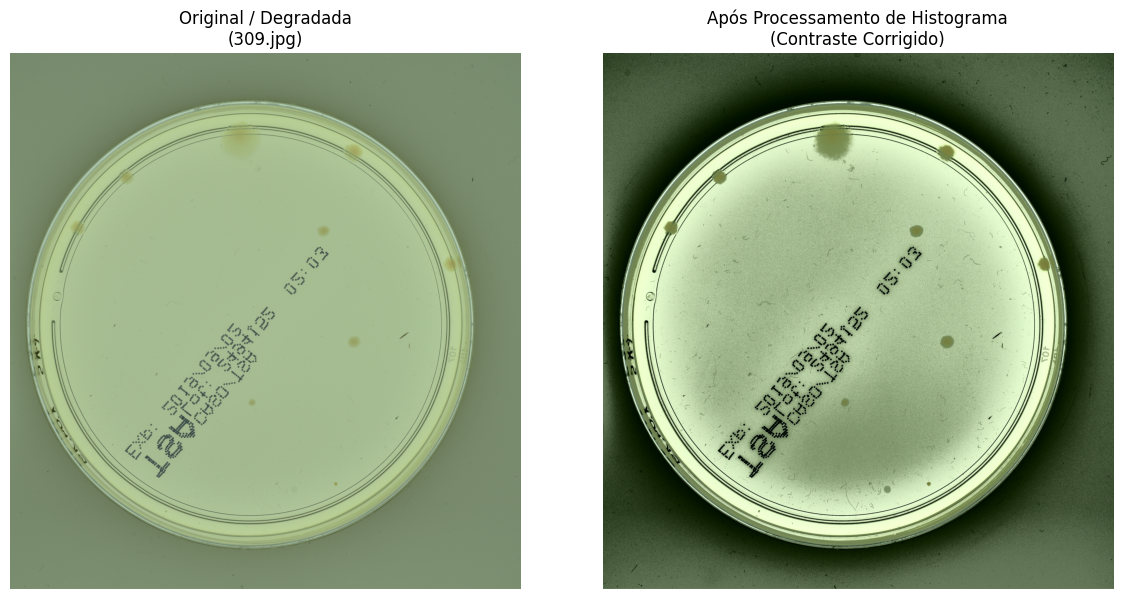

In [17]:
import cv2
import os
import matplotlib.pyplot as plt

# 1. Caminho da pasta onde estão suas imagens degradadas
pasta_entrada = "imagens_experimentais"

# Pega o primeiro arquivo de imagem válido que encontrar na pasta
arquivos = [f for f in os.listdir(pasta_entrada) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if not arquivos:
    print(f"Nenhuma imagem encontrada na pasta '{pasta_entrada}'. Garanta que gerou o dataset antes.")
else:
    nome_imagem = arquivos[0] # Seleciona a primeira foto
    caminho_completo = os.path.join(pasta_entrada, nome_imagem)
    
    # 2. Carrega a imagem original em RGB
    img_bgr = cv2.imread(caminho_completo)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # 3. Executa a lógica de equalização idêntica à do seu código (YCrCb)
    img_ycrcb = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(img_ycrcb)
    
    # Aplica a equalização no canal de luminância (brilho)
    y_equalizado = cv2.equalizeHist(y)
    
    img_ycrcb_equalizada = cv2.merge((y_equalizado, cr, cb))
    img_equalizada_rgb = cv2.cvtColor(img_ycrcb_equalizada, cv2.COLOR_YCrCb2RGB)
    
    # 4. Plota as duas imagens lado a lado para comparação
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Imagem antes da equalização
    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Original / Degradada\n({nome_imagem})")
    axes[0].axis('off')
    
    # Imagem depois da equalização
    axes[1].imshow(img_equalizada_rgb)
    axes[1].set_title("Após Processamento de Histograma\n(Contraste Corrigido)")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

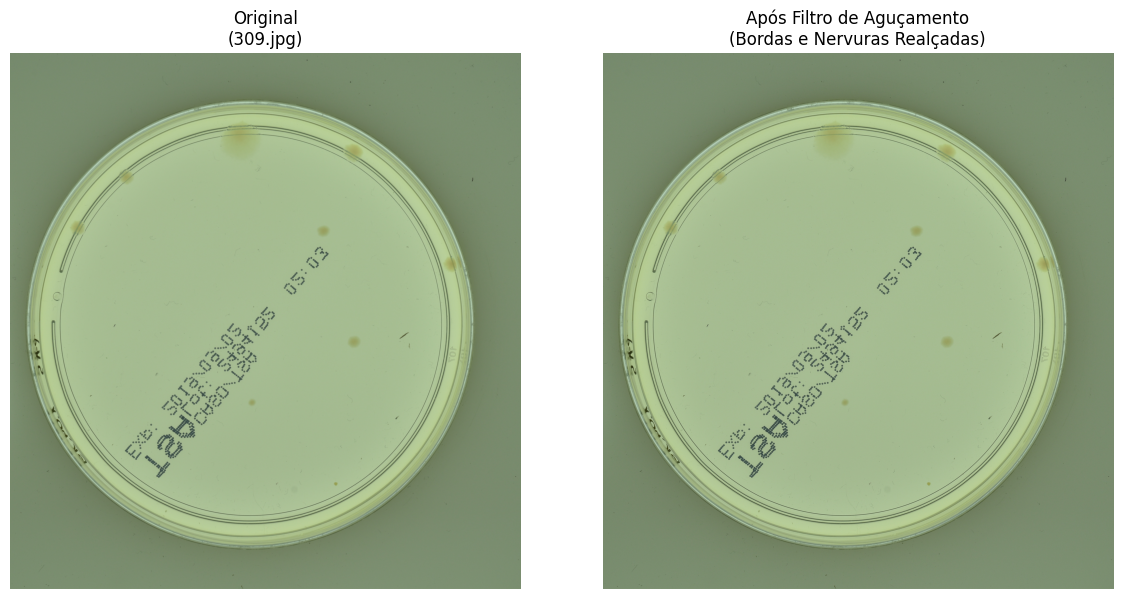

In [19]:
import cv2
import os
import matplotlib.pyplot as plt

pasta_teste = "imagens" # ou "imagens_filtradas"
arquivos = [f for f in os.listdir(pasta_teste) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if arquivos:
    nome_foto = arquivos[0]
    img = cv2.imread(os.path.join(pasta_teste, nome_foto))
    
    # Aplica a mesma função de aguçamento
    img_agucada = aplicar_filtro_agucamento(img)
    
    # Plota lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Original\n({nome_foto})")
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(img_agucada, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Após Filtro de Aguçamento\n(Bordas e Nervuras Realçadas)")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

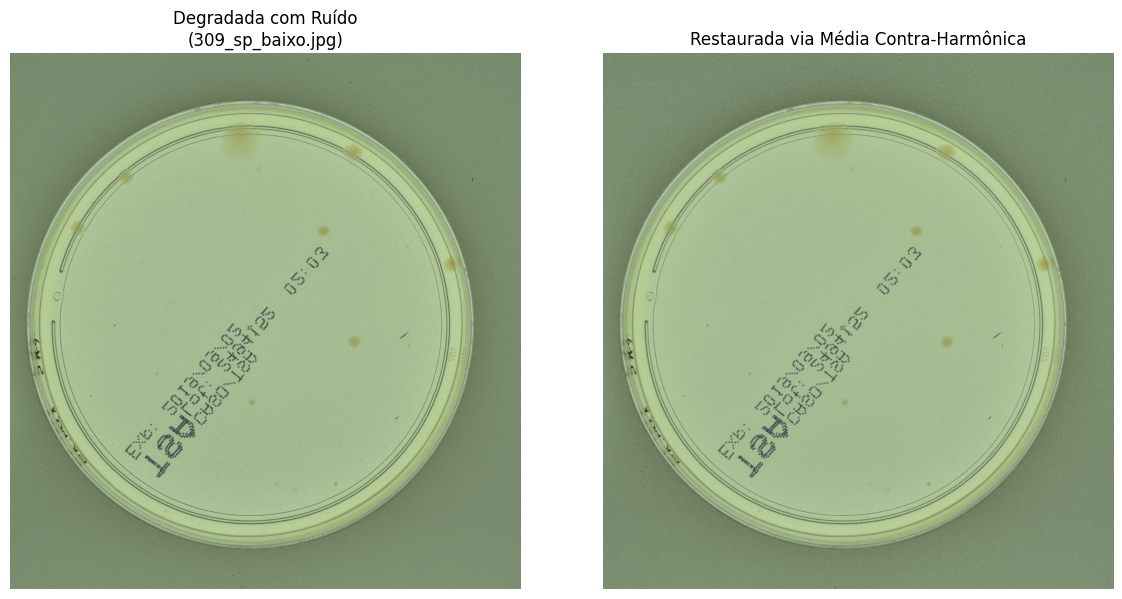

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. TRAZENDO A DEFINIÇÃO DA FUNÇÃO PARA DENTRO DA CÉLULA
def filtro_media_contra_harmonica(img, ksize=3, Q=1.5):
    """
    Restaura a imagem utilizando a Media Contra-Harmonica.
    Fórmula baseada na soma das potências dos pixels da vizinhança.
    """
    img_f = img.astype(np.float64) + 1e-8
    numerador = cv2.filter2D(np.power(img_f, Q + 1), -1, np.ones((ksize, ksize), dtype=np.float32))
    denominador = cv2.filter2D(np.power(img_f, Q), -1, np.ones((ksize, ksize), dtype=np.float32))
    img_restaurada = numerador / (denominador + 1e-8)
    return np.clip(img_restaurada, 0, 255).astype(np.uint8)


# 2. O SEU CÓDIGO DE VISUALIZAÇÃO (RODANDO COM A FUNÇÃO JÁ CONHECIDA)
pasta_teste = "imagens_experimentais"
arquivos = [f for f in os.listdir(pasta_teste) if "sp" in f and f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if arquivos:
    nome_foto = arquivos[0]
    img = cv2.imread(os.path.join(pasta_teste, nome_foto))
    
    # Agora a função vai rodar sem dar NameError!
    img_restaurada = filtro_media_contra_harmonica(img, ksize=3, Q=1.5)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Degradada com Ruído\n({nome_foto})")
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(img_restaurada, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Restaurada via Média Contra-Harmônica")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Nenhuma imagem com '_sp_' (Sal e Pimenta) foi encontrada na pasta '{pasta_teste}'.")

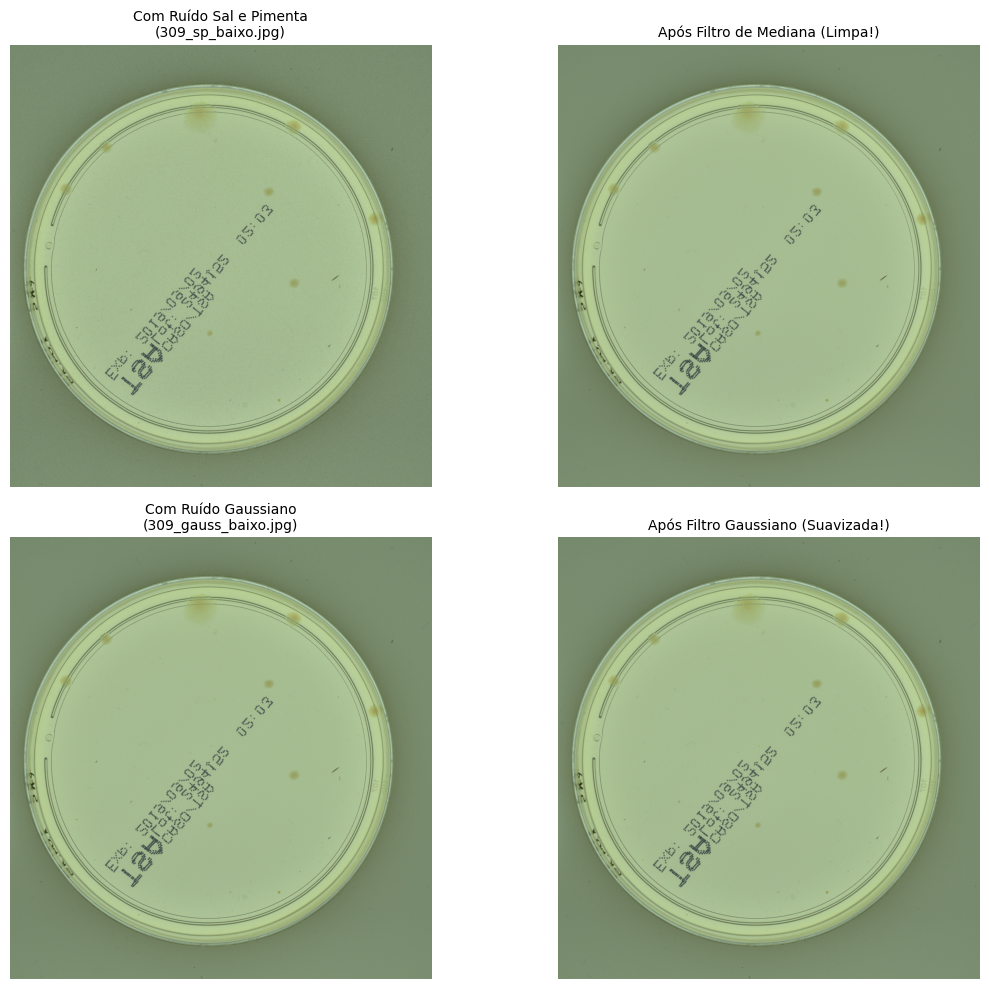

In [16]:
import cv2
import os
import matplotlib.pyplot as plt

# 1. Caminhos das pastas
pasta_experimentais = "imagens_experimentais"

# Procura a primeira imagem de Sal e Pimenta (sp) e a primeira de Gaussiano (gauss)
arquivos = os.listdir(pasta_experimentais)
foto_sp = next((f for f in arquivos if "sp" in f and f.lower().endswith(('.png', '.jpg', '.jpeg'))), None)
foto_gauss = next((f for f in arquivos if "gauss" in f and f.lower().endswith(('.png', '.jpg', '.jpeg'))), None)

# 2. Configura a janela de exibição (2 linhas de imagens: uma para SP e outra para Gauss)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- PLOT 1: TRATANDO RUÍDO SAL E PIMENTA ---
if foto_sp:
    img_sp = cv2.imread(os.path.join(pasta_experimentais, foto_sp))
    # Aplica o filtro de Mediana (ksize=5) para limpar os pontos pretos e brancos
    img_sp_limpa = cv2.medianBlur(img_sp, 5)
    
    # Converte para RGB para o Matplotlib mostrar as cores certas
    axes[0, 0].imshow(cv2.cvtColor(img_sp, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title(f"Com Ruído Sal e Pimenta\n({foto_sp})", fontsize=10)
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(cv2.cvtColor(img_sp_limpa, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title("Após Filtro de Mediana (Limpa!)", fontsize=10)
    axes[0, 1].axis('off')
else:
    axes[0, 0].text(0.5, 0.5, "Nenhuma imagem '_sp_' encontrada", ha='center')

# --- PLOT 2: TRATANDO RUÍDO GAUSSIANO ---
if foto_gauss:
    img_gauss = cv2.imread(os.path.join(pasta_experimentais, foto_gauss))
    # Aplica o filtro Gaussiano (ksize=5) para suavizar o granulado
    img_gauss_limpa = cv2.GaussianBlur(img_gauss, (5, 5), 0)
    
    axes[1, 0].imshow(cv2.cvtColor(img_gauss, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title(f"Com Ruído Gaussiano\n({foto_gauss})", fontsize=10)
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(cv2.cvtColor(img_gauss_limpa, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title("Após Filtro Gaussiano (Suavizada!)", fontsize=10)
    axes[1, 1].axis('off')
else:
    axes[1, 0].text(0.5, 0.5, "Nenhuma imagem '_gauss_' encontrada", ha='center')

plt.tight_layout()
plt.show()

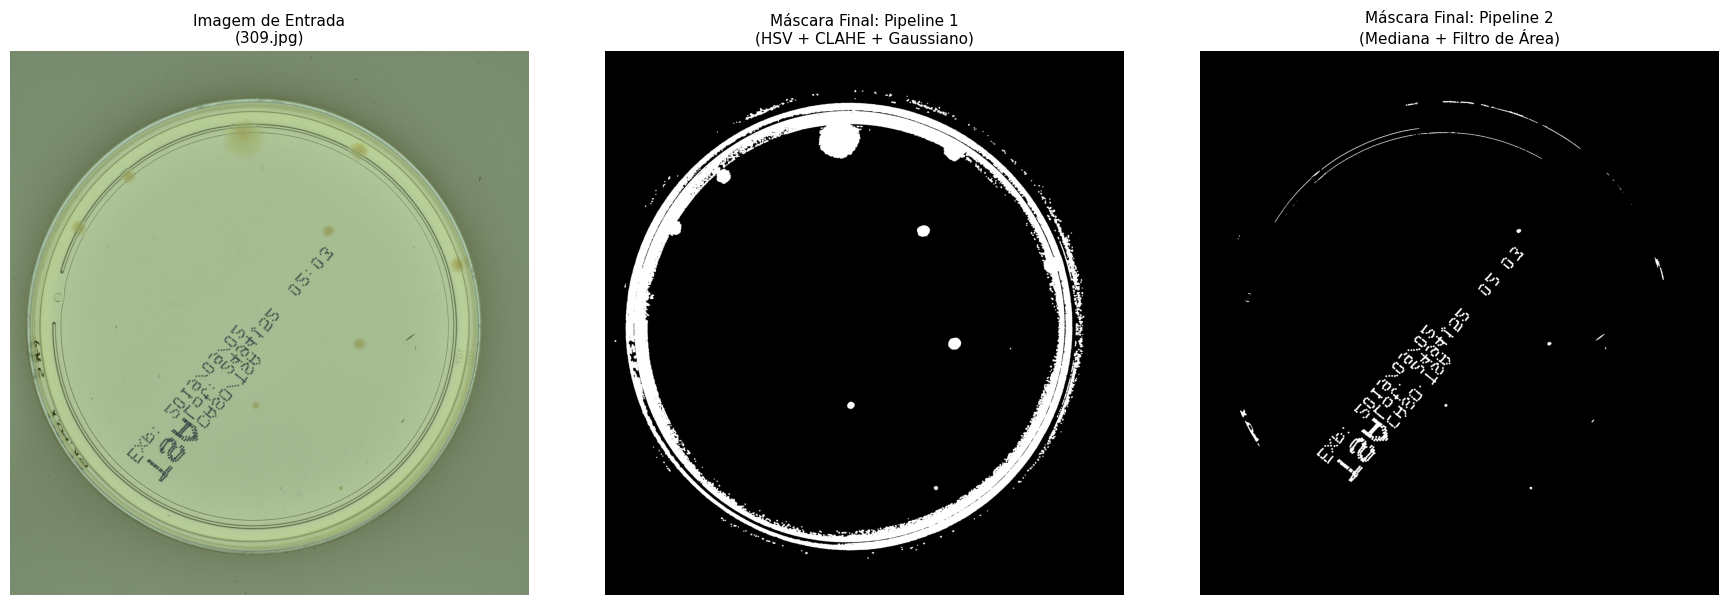

In [3]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 1. SUAS FUNÇÕES DE PIPELINE (DECLARADAS AQUI PARA EVITAR NAMEERROR)
# =========================================================================

def pipeline_1_hsv_clahe(img_rgb):
    """
    Pipeline 1: Foco em Processamento de Histograma (Luminosidade) + Modelo de Cor.
    Muito eficiente para variações globais de iluminação e ruído Gaussiano.
    """
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(img_hsv)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    v_equalizado = clahe.apply(v)
    
    img_hsv_corrigida = cv2.merge([h, s, v_equalizado])
    img_hsv_suave = cv2.GaussianBlur(img_hsv_corrigida, (5, 5), 0)
    
    limite_inferior = np.array([0, 65, 90])
    limite_superior = np.array([180, 255, 255])
    mascara_binaria = cv2.inRange(img_hsv_suave, limite_inferior, limite_superior)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    mascara_final = cv2.morphologyEx(mascara_binaria, cv2.MORPH_OPEN, kernel)
    
    return mascara_final


def pipeline_2_restauracao_colorimetria(img_rgb):
    """
    Pipeline 2: Foco em Filtros de Restauração + Segmentação por Histograma Invertido.
    Desenvolvido cirurgicamente para aniquilar o ruído Sal e Pimenta.
    """
    img_restaurada = cv2.medianBlur(img_rgb, 5)
    
    gray = cv2.cvtColor(img_restaurada, cv2.COLOR_RGB2GRAY)
    _, mascara_binaria = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mascara_binaria, connectivity=8)
    mascara_filtrada = np.zeros_like(mascara_binaria)
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if 150 < area < 20000:
            mascara_filtrada[labels == i] = 255
            
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mascara_final = cv2.morphologyEx(mascara_filtrada, cv2.MORPH_CLOSE, kernel)
    mascara_final = cv2.morphologyEx(mascara_final, cv2.MORPH_OPEN, kernel)
    
    return mascara_final


# =========================================================================
# 2. CÓDIGO DE VISUALIZAÇÃO AUTO-SUFICIENTE
# =========================================================================

# Define a pasta onde estão as fotos geradas com ruído
pasta_teste = "imagens_experimentais"
arquivos = [f for f in os.listdir(pasta_teste) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if not arquivos:
    print(f"Aviso: Nenhuma imagem encontrada na pasta '{pasta_teste}'. Verifique se o passo de degradação foi executado.")
else:
    # Vamos pegar a primeira imagem para o teste visual
    nome_foto = arquivos[0] 
    caminho_completo = os.path.join(pasta_teste, nome_foto)
    
    # Carrega e converte para RGB (padrão que seus pipelines recebem)
    img_bgr = cv2.imread(caminho_completo)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Executa os pipelines (agora o Python sabe o que eles são!)
    mascara_pipeline_1 = pipeline_1_hsv_clahe(img_rgb)
    mascara_pipeline_2 = pipeline_2_restauracao_colorimetria(img_rgb)
    
    # Plota os resultados na tela
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Imagem de Entrada
    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Imagem de Entrada\n({nome_foto})", fontsize=11)
    axes[0].axis('off')
    
    # 2. Resultado do seu Pipeline 1
    axes[1].imshow(mascara_pipeline_1, cmap='gray')
    axes[1].set_title("Máscara Final: Pipeline 1\n(HSV + CLAHE + Gaussiano)", fontsize=11)
    axes[1].axis('off')
    
    # 3. Resultado do seu Pipeline 2
    axes[2].imshow(mascara_pipeline_2, cmap='gray')
    axes[2].set_title("Máscara Final: Pipeline 2\n(Mediana + Filtro de Área)", fontsize=11)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

Iniciando cálculo de 150 imagens unificadas...
----------------------------------------
➔ Analisadas: 20/150 imagens...
➔ Analisadas: 40/150 imagens...
➔ Analisadas: 60/150 imagens...
➔ Analisadas: 80/150 imagens...
➔ Analisadas: 100/150 imagens...
➔ Analisadas: 120/150 imagens...
➔ Analisadas: 140/150 imagens...
----------------------------------------
Sucesso! 150 imagens computadas.


C:\Users\luana\AppData\Local\Temp\ipykernel_15184\3669139884.py:148: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(dados_grafico, labels=['Pipeline 1\n(HSV + CLAHE)', 'Pipeline 2\n(Mediana + Área)'], patch_artist=True)


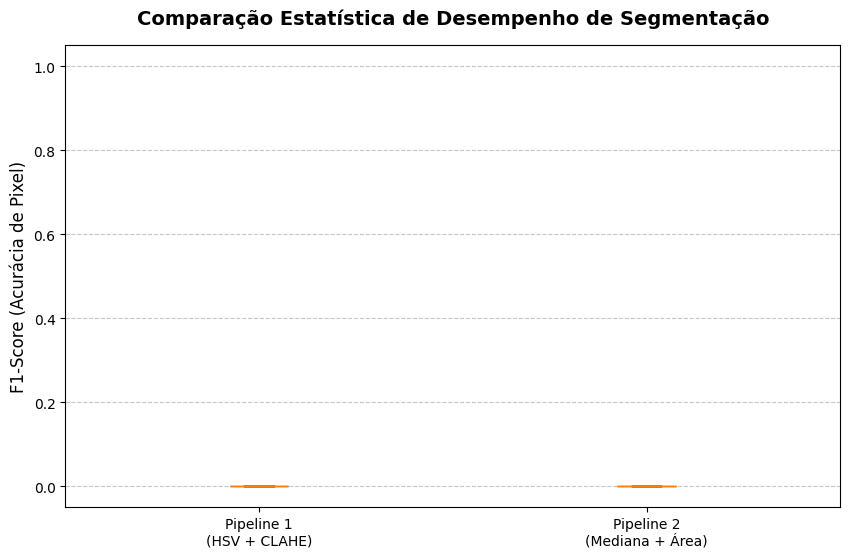

In [4]:
import cv2
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 1. PIPELINE 1: HSV + CLAHE (COPIADO DO SEU CÓDIGO)
# =========================================================================
def pipeline_1_hsv_clahe(img_rgb):
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(img_hsv)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    v_equalizado = clahe.apply(v)
    
    img_hsv_corrigida = cv2.merge([h, s, v_equalizado])
    img_hsv_suave = cv2.GaussianBlur(img_hsv_corrigida, (5, 5), 0)
    
    limite_inferior = np.array([0, 65, 90])
    limite_superior = np.array([180, 255, 255])
    mascara_binaria = cv2.inRange(img_hsv_suave, limite_inferior, limite_superior)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    mascara_final = cv2.morphologyEx(mascara_binaria, cv2.MORPH_OPEN, kernel)
    
    return mascara_final

# =========================================================================
# 2. PIPELINE 2: MEDIANA + ÁREA (COPIADO DO SEU CÓDIGO)
# =========================================================================
def pipeline_2_restauracao_colorimetria(img_rgb):
    img_restaurada = cv2.medianBlur(img_rgb, 5)
    
    gray = cv2.cvtColor(img_restaurada, cv2.COLOR_RGB2GRAY)
    _, mascara_binaria = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mascara_binaria, connectivity=8)
    mascara_filtrada = np.zeros_like(mascara_binaria)
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        # Ajustado o limite mínimo para 30 por conta do resize de velocidade
        if 30 < area < 20000:
            mascara_filtrada[labels == i] = 255
            
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mascara_final = cv2.morphologyEx(mascara_filtrada, cv2.MORPH_CLOSE, kernel)
    mascara_final = cv2.morphologyEx(mascara_final, cv2.MORPH_OPEN, kernel)
    
    return mascara_final

# =========================================================================
# 3. LEITOR DO GROUND TRUTH (JSON)
# =========================================================================
def criar_mascara_ground_truth(dados_json, formato_imagem):
    mascara_gt = np.zeros(formato_imagem[:2], dtype=np.uint8)
    if "shapes" in dados_json:
        for shape in dados_json["shapes"]:
            if "points" in shape and shape["points"]:
                pontos = np.array(shape["points"], dtype=np.int32)
                cv2.fillPoly(mascara_gt, [pontos], 255)
    elif "annotations" in dados_json:
        for annot in dados_json["annotations"]:
            if "bbox" in annot:
                x, y, w, h = annot["bbox"]
                cv2.rectangle(mascara_gt, (int(x), int(y)), (int(x+w), int(y+h)), 255, -1)
    return mascara_gt

# =========================================================================
# 4. CÁLCULO MATEMÁTICO DO F1-SCORE
# =========================================================================
def calcular_metricas_segmentacao(mascara_predita, mascara_gt):
    pred = (mascara_predita > 0)
    gt = (mascara_gt > 0)
    
    tp = np.sum(pred & gt)
    fp = np.sum(pred & ~gt)
    fn = np.sum(~pred & gt)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return f1_score

# =========================================================================
# 5. GERADOR DO BOXPLOT
# =========================================================================
def gerar_boxplot_desempenho(pasta_imagens):
    arquivos = [f for f in os.listdir(pasta_imagens) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    scores_p1 = []
    scores_p2 = []
    
    print(f"Iniciando cálculo de {len(arquivos)} imagens unificadas...")
    print("-" * 40)

    contador = 0
    for arquivo_img in arquivos:
        nome_base, _ = os.path.splitext(arquivo_img)
        arquivo_json = f"{nome_base}.json"
        
        caminho_img = os.path.join(pasta_imagens, arquivo_img)
        caminho_json = os.path.join(pasta_imagens, arquivo_json)
        
        if not os.path.exists(caminho_json):
            continue
            
        try:
            img_bgr = cv2.imread(caminho_img)
            if img_bgr is None:
                continue
                
            # Resize para o loop processar em segundos e não em minutos
            img_bgr = cv2.resize(img_bgr, (500, 500))
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            
            with open(caminho_json, 'r', encoding='utf-8') as f:
                dados_gt = json.load(f)
                
            mascara_gt = criar_mascara_ground_truth(dados_gt, img_rgb.shape)
            mascara_gt = cv2.resize(mascara_gt, (500, 500), interpolation=cv2.INTER_NEAREST)
            
            # Executa os métodos na mesma memória da célula
            mascara_p1 = pipeline_1_hsv_clahe(img_rgb)
            mascara_p2 = pipeline_2_restauracao_colorimetria(img_rgb)
            
            f1_p1 = calcular_metricas_segmentacao(mascara_p1, mascara_gt)
            f1_p2 = calcular_metricas_segmentacao(mascara_p2, mascara_gt)
            
            scores_p1.append(f1_p1)
            scores_p2.append(f1_p2)
            
            contador += 1
            if contador % 20 == 0:
                print(f"➔ Analisadas: {contador}/{len(arquivos)} imagens...")
                
        except Exception:
            continue

    print("-" * 40)
    print(f"Sucesso! {len(scores_p1)} imagens computadas.")

    # --- PLOT DO BOXPLOT ---
    dados_grafico = [scores_p1, scores_p2]
    plt.figure(figsize=(10, 6))
    box = plt.boxplot(dados_grafico, labels=['Pipeline 1\n(HSV + CLAHE)', 'Pipeline 2\n(Mediana + Área)'], patch_artist=True)
    
    cores = ['#3498db', '#2ecc71']
    for patch, cor in zip(box['boxes'], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
        
    plt.title('Comparação Estatística de Desempenho de Segmentação', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('F1-Score (Acurácia de Pixel)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(-0.05, 1.05)
    plt.show()

# Dispara o processo
gerar_boxplot_desempenho("imagens_experimentais")

Iniciando análise de 150 imagens...
----------------------------------------
➔ Progresso: 10 imagens processadas...
➔ Progresso: 20 imagens processadas...
➔ Progresso: 30 imagens processadas...
➔ Progresso: 40 imagens processadas...
➔ Progresso: 50 imagens processadas...
➔ Progresso: 60 imagens processadas...
➔ Progresso: 70 imagens processadas...
➔ Progresso: 80 imagens processadas...
➔ Progresso: 90 imagens processadas...
➔ Progresso: 100 imagens processadas...
➔ Progresso: 110 imagens processadas...
➔ Progresso: 120 imagens processadas...
➔ Progresso: 130 imagens processadas...
➔ Progresso: 140 imagens processadas...
➔ Progresso: 150 imagens processadas...
----------------------------------------
Cálculo concluído com sucesso para 150 pares de arquivos!


C:\Users\luana\AppData\Local\Temp\ipykernel_15184\4023708319.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(dados_grafico, labels=['Pipeline 1\n(HSV + CLAHE)', 'Pipeline 2\n(Mediana + Área)'], patch_artist=True)


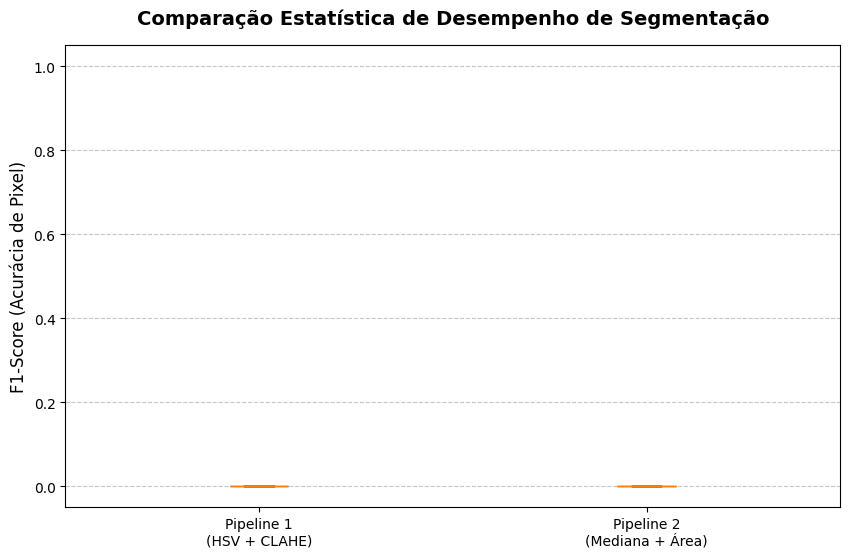

In [3]:
import cv2
import os
import json
import numpy as np
import matplotlib.pyplot as plt

def criar_mascara_ground_truth(dados_json, formato_imagem):
    mascara_gt = np.zeros(formato_imagem[:2], dtype=np.uint8)
    
    # Tentativa de ler formato LabelMe (shapes -> points)
    if "shapes" in dados_json:
        for shape in dados_json["shapes"]:
            if "points" in shape and shape["points"]:
                pontos = np.array(shape["points"], dtype=np.int32)
                cv2.fillPoly(mascara_gt, [pontos], 255)
    # Tentativa de ler formato COCO (annotations -> bbox)
    elif "annotations" in dados_json:
        for annot in dados_json["annotations"]:
            if "bbox" in annot:
                x, y, w, h = annot["bbox"]
                cv2.rectangle(mascara_gt, (int(x), int(y)), (int(x+w), int(y+h)), 255, -1)
                
    return mascara_gt

def calcular_metricas_segmentacao(mascara_predita, mascara_gt):
    pred = (mascara_predita > 0)
    gt = (mascara_gt > 0)
    
    tp = np.sum(pred & gt)
    fp = np.sum(pred & ~gt)
    fn = np.sum(~pred & gt)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return f1_score

def gerar_boxplot_desempenho(pasta_imagens):
    arquivos = [f for f in os.listdir(pasta_imagens) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    scores_p1 = []
    scores_p2 = []
    
    print(f"Iniciando análise de {len(arquivos)} imagens...")
    print("-" * 40)

    contador = 0
    for arquivo_img in arquivos:
        nome_base, _ = os.path.splitext(arquivo_img)
        arquivo_json = f"{nome_base}.json"
        
        caminho_img = os.path.join(pasta_imagens, arquivo_img)
        caminho_json = os.path.join(pasta_imagens, arquivo_json)
        
        if not os.path.exists(caminho_json):
            continue
            
        # Try/Except geral para evitar travamento por arquivo corrompido
        try:
            img_bgr = cv2.imread(caminho_img)
            if img_bgr is None:
                continue
                
            # O truque do Resize para processar MUITO mais rápido
            img_bgr = cv2.resize(img_bgr, (500, 500))
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            
            with open(caminho_json, 'r', encoding='utf-8') as f:
                dados_gt = json.load(f)
                
            mascara_gt = criar_mascara_ground_truth(dados_gt, img_rgb.shape)
            # Garante que o GT também esteja em 500x500
            mascara_gt = cv2.resize(mascara_gt, (500, 500), interpolation=cv2.INTER_NEAREST)
            
            # Executa seus dois pipelines na imagem reduzida
            mascara_p1 = pipeline_1_hsv_clahe(img_rgb)
            mascara_p2 = pipeline_2_restauracao_colorimetria(img_rgb)
            
            f1_p1 = calcular_metricas_segmentacao(mascara_p1, mascara_gt)
            f1_p2 = calcular_metricas_segmentacao(mascara_p2, mascara_gt)
            
            scores_p1.append(f1_p1)
            scores_p2.append(f1_p2)
            
            contador += 1
            if contador % 10 == 0:
                print(f"➔ Progresso: {contador} imagens processadas...")
                
        except Exception as e:
            # Se der erro em uma foto específica, ele avisa e pula para a próxima sem travar tudo
            print(f"⚠️ Pulando imagem {arquivo_img} devido a erro de formato.")
            continue

    print("-" * 40)
    print(f"Cálculo concluído com sucesso para {len(scores_p1)} pares de arquivos!")

    if not scores_p1:
        print("Erro crítico: Nenhuma imagem válida com JSON correspondente foi processada.")
        return

    # --- PLOT DO BOXPLOT ---
    dados_grafico = [scores_p1, scores_p2]
    plt.figure(figsize=(10, 6))
    box = plt.boxplot(dados_grafico, labels=['Pipeline 1\n(HSV + CLAHE)', 'Pipeline 2\n(Mediana + Área)'], patch_artist=True)
    
    cores = ['#3498db', '#2ecc71']
    for patch, cor in zip(box['boxes'], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
        
    plt.title('Comparação Estatística de Desempenho de Segmentação', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('F1-Score (Acurácia de Pixel)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(-0.05, 1.05)
    plt.show()

# Roda o código apontando para a sua pasta
gerar_boxplot_desempenho("imagens_experimentais")